In [ ]:

%load_ext autoreload
%autoreload 2
import sys

import matplotlib.pyplot as plt
import xarray as xr

local_src = "/scratch/synced/src"
sys.path.insert(0, local_src)

for m in list(sys.modules):
    if m == "srm" or m.startswith("srm."):
        del sys.modules[m]

from srm import catalog
from srm.plotting import (
    calculate_statistic_to_plot,
    plot_cdf,
    plot_comparisons,
    plot_pdf,
    plot_timeseries,
    prep_datasets_for_daily_timeseries_plotting,
    prep_datasets_for_seasonal_cycle_plotting,
    sel_point,
)
from srm.utils import clean_up_dataset, convert_precip_units, icechunk_store_to_dataset

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
ds1 = xr.open_dataset(
    "s3://carbonplan-srm/output/v0.2/pr_model_hist_BCSD_nonparametric.nc", engine="h5netcdf"
)
ds2 = xr.open_dataset(
    "s3://carbonplan-srm/output/v0.2/pr_model_hist_BCSD_parametric.nc", engine="h5netcdf"
)

In [42]:
variables = ["pr", "tas"]

In [43]:
era5 = icechunk_store_to_dataset("ERA5", catalog)
era5 = clean_up_dataset(era5, "ERA5")[variables]

In [44]:
gcm = "CESM2-WACCM"  # TODO - once dataset name is fixed this should update to CESM2
scenario = "Historical"  # "SSP245" # #  # "G6-1.5K"
dataset_name = f"{gcm}-{scenario}-icechunk"
ensemble_member = "007"
# TODO: make the training period an attr in the dataset
training_period = slice("1978-01-01", "2014-12-31")
# this will restrict the domain to the spatial extent of ds1
lon_max, lon_min = ds1.longitude.max().values, ds1.longitude.min().values
lat_max, lat_min = ds1.latitude.max().values, ds1.latitude.min().values

In [45]:
raw = icechunk_store_to_dataset(dataset_name, catalog)

In [46]:
raw = clean_up_dataset(raw, gcm)[variables]

In [47]:
# for this set-up we'll convert precip units to all be on mm/day
ds1 = convert_precip_units(ds1, "ERA5")
ds1 = ds1.drop("spatial_ref")
if ds2 is not None:
    ds2 = convert_precip_units(ds2, "ERA5")
    ds2 = ds2.drop("spatial_ref")

/tmp/ipykernel_73640/4216431243.py:3: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds1 = ds1.drop('spatial_ref')
/tmp/ipykernel_73640/4216431243.py:6: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds2 = ds2.drop('spatial_ref')


In [48]:
variable = variables[0]

In [49]:
raw = raw.sel(
    time=training_period, latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max)
)
era5 = era5.sel(
    time=training_period, latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max)
)
ds1 = ds1.sel(time=training_period)
ds2 = ds2.sel(time=training_period)

In [51]:
# team TODO: remove this temporal subsetting *once this notebook development complete* (i.e. when merging into main).
# i include it now because while in development, it's helpful to subset to a single year to
# speed up the processing and make it easier to run repeatedly
raw_pr_toplot, era5_pr_toplot, ds1_pr_toplot, ds2_pr_toplot = calculate_statistic_to_plot(
    raw.isel(time=slice(0, 365)),
    era5.isel(time=slice(0, 365)),
    ds1.isel(time=slice(0, 365)),
    "mean",
    "pr",
    ds2=ds2.isel(time=slice(0, 365)),
)

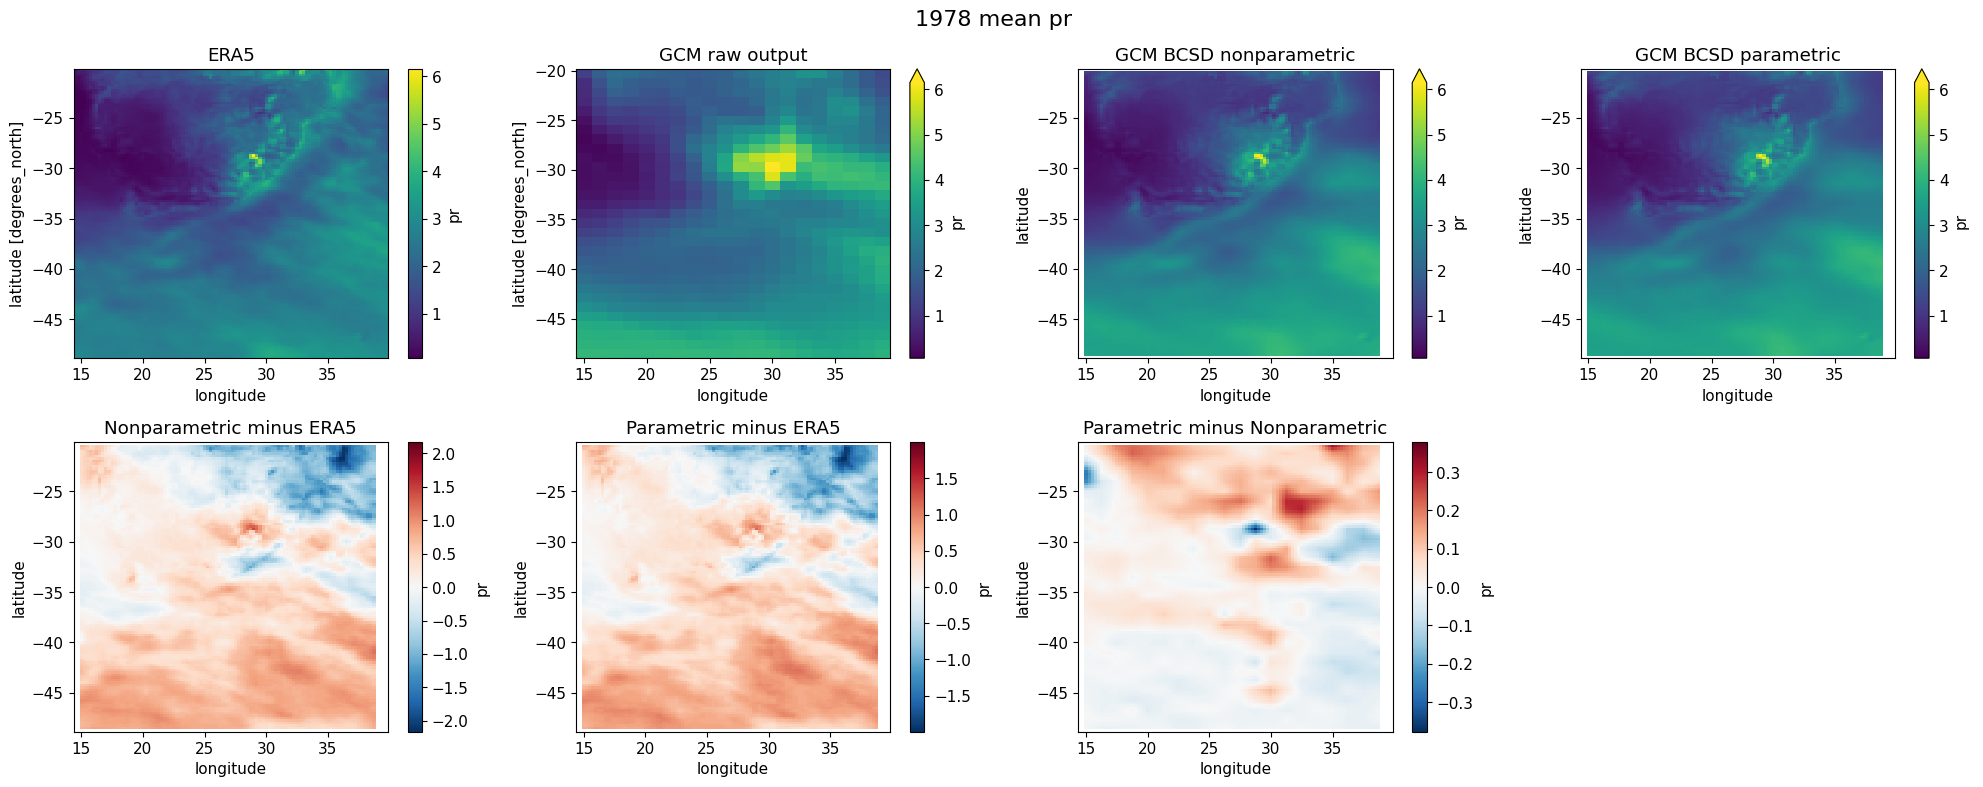

In [52]:
plot_comparisons(era5_pr_toplot, raw_pr_toplot, ds1_pr_toplot, ds2_pr_toplot)

In [53]:
raw_99p_toplot, era5_99p_toplot, ds1_99p_toplot, ds2_99p_toplot = calculate_statistic_to_plot(
    raw.isel(time=slice(0, 365)),
    era5.isel(time=slice(0, 365)),
    ds1.isel(time=slice(0, 365)),
    "99p",
    "pr",
    ds2=ds2.isel(time=slice(0, 365)),
)

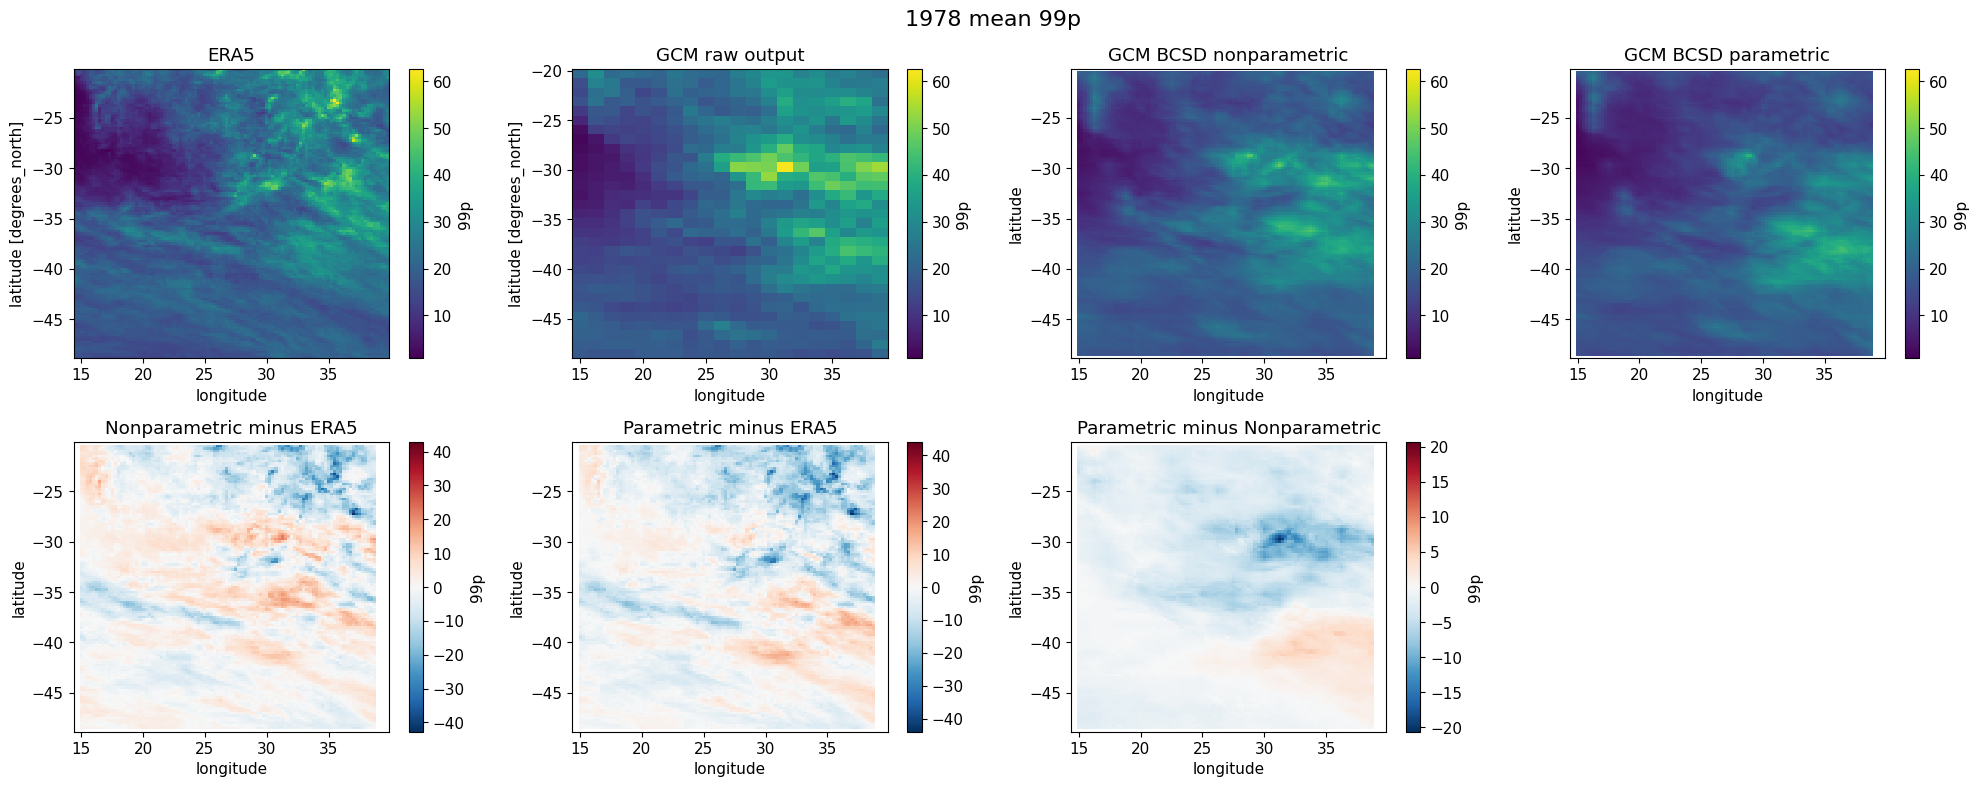

In [54]:
plot_comparisons(era5_99p_toplot, raw_99p_toplot, ds1_99p_toplot, ds2_99p_toplot)

In [55]:
raw_dd_toplot, era5_dd_toplot, ds1_dd_toplot, ds2_dd_toplot = calculate_statistic_to_plot(
    raw.isel(time=slice(0, 365)),
    era5.isel(time=slice(0, 365)),
    ds1.isel(time=slice(0, 365)),
    "dry_days",
    "pr",
    ds2=ds2.isel(time=slice(0, 365)),
)

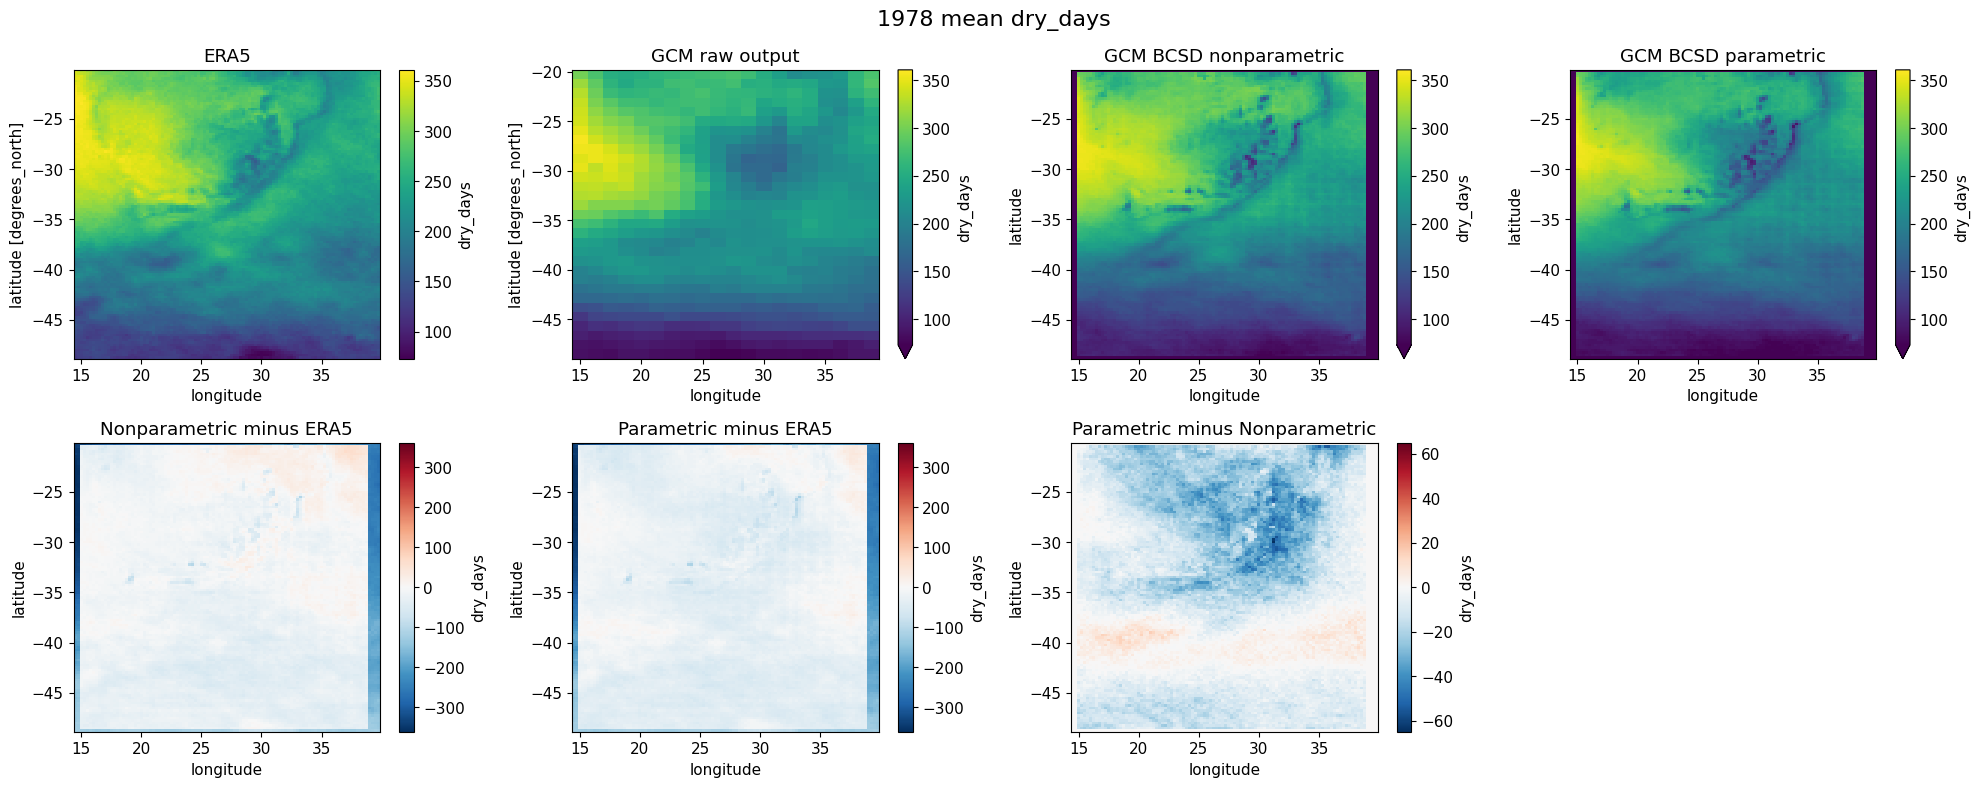

In [56]:
plot_comparisons(era5_dd_toplot, raw_dd_toplot, ds1_dd_toplot, ds2_dd_toplot)

In [57]:
# Now plot temperature variables
ds1_tas = xr.open_dataset(
    "s3://carbonplan-srm/output/v0.2/tas_model_hist_BCSD_nonparametric.nc", engine="h5netcdf"
)
ds2_tas = xr.open_dataset(
    "s3://carbonplan-srm/output/v0.2/tas_model_hist_BCSD_parametric.nc", engine="h5netcdf"
)

In [58]:
ds1_tas = ds1_tas.sel(time=training_period)
ds2_tas = ds2_tas.sel(time=training_period)

In [59]:
raw_tas_toplot, era5_tas_toplot, ds1_tas_toplot, ds2_tas_toplot = calculate_statistic_to_plot(
    raw.isel(time=slice(0, 365)),
    era5.isel(time=slice(0, 365)),
    ds1_tas.isel(time=slice(0, 365)),
    "mean",
    "tas",
    ds2=ds2_tas.isel(time=slice(0, 365)),
)

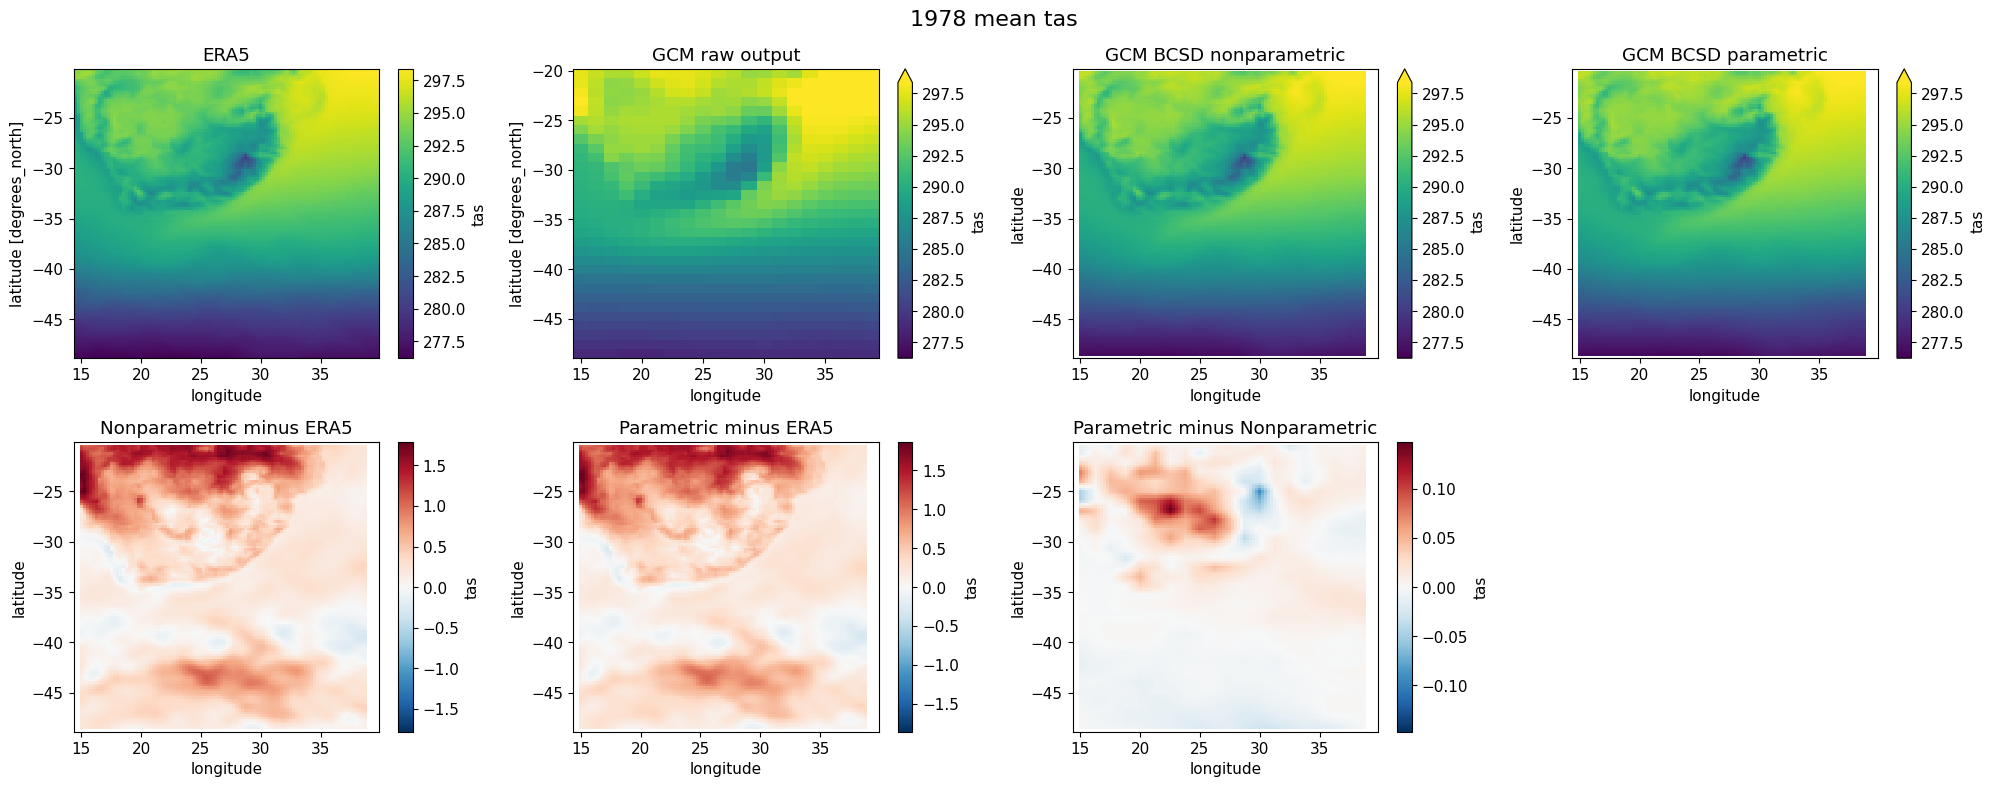

In [60]:
plot_comparisons(era5_tas_toplot, raw_tas_toplot, ds1_tas_toplot, ds2_tas_toplot)

In [61]:
raw_hot_day_toplot, era5_hot_day_toplot, ds1_hot_day_toplot, ds2_hot_day_toplot = (
    calculate_statistic_to_plot(
        raw.isel(time=slice(0, 365)),
        era5.isel(time=slice(0, 365)),
        ds1_tas.isel(time=slice(0, 365)),
        "hottest_day",
        "tas",
        ds2=ds2_tas.isel(time=slice(0, 365)),
    )
)

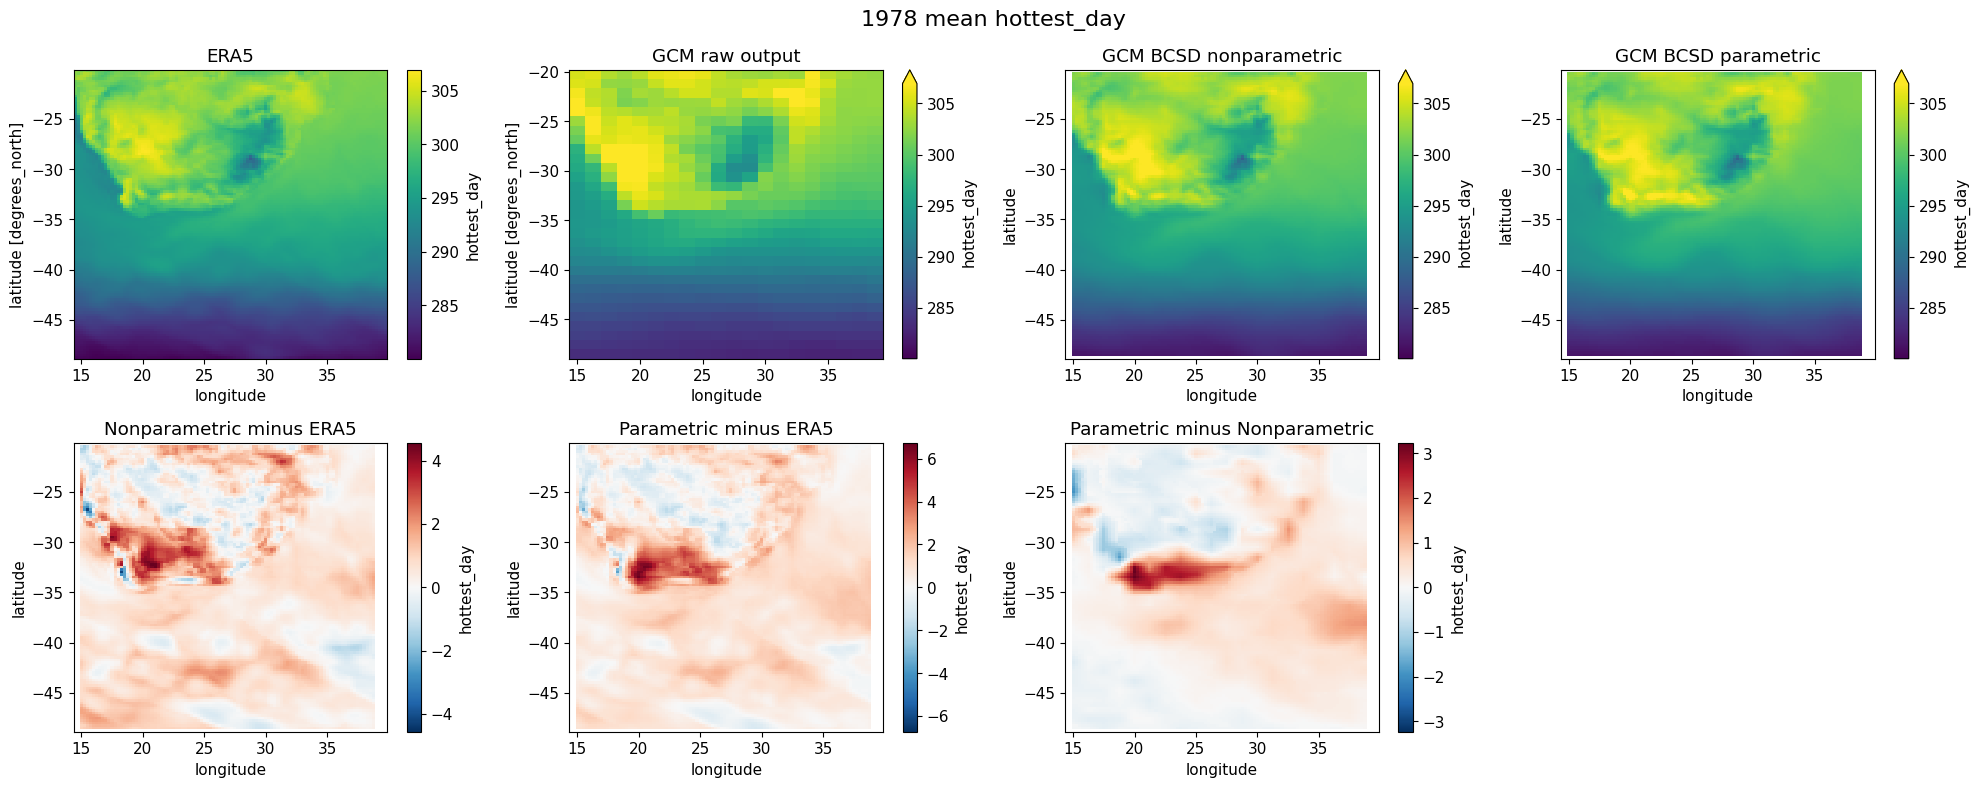

In [62]:
plot_comparisons(era5_hot_day_toplot, raw_hot_day_toplot, ds1_hot_day_toplot, ds2_hot_day_toplot)

In [63]:
raw_gdd_toplot, era5_gdd_toplot, ds1_gdd_toplot, ds2_gdd_toplot = calculate_statistic_to_plot(
    raw.isel(time=slice(0, 365)),
    era5.isel(time=slice(0, 365)),
    ds1_tas.isel(time=slice(0, 365)),
    "gdd",
    "tas",
    ds2=ds2_tas.isel(time=slice(0, 365)),
)

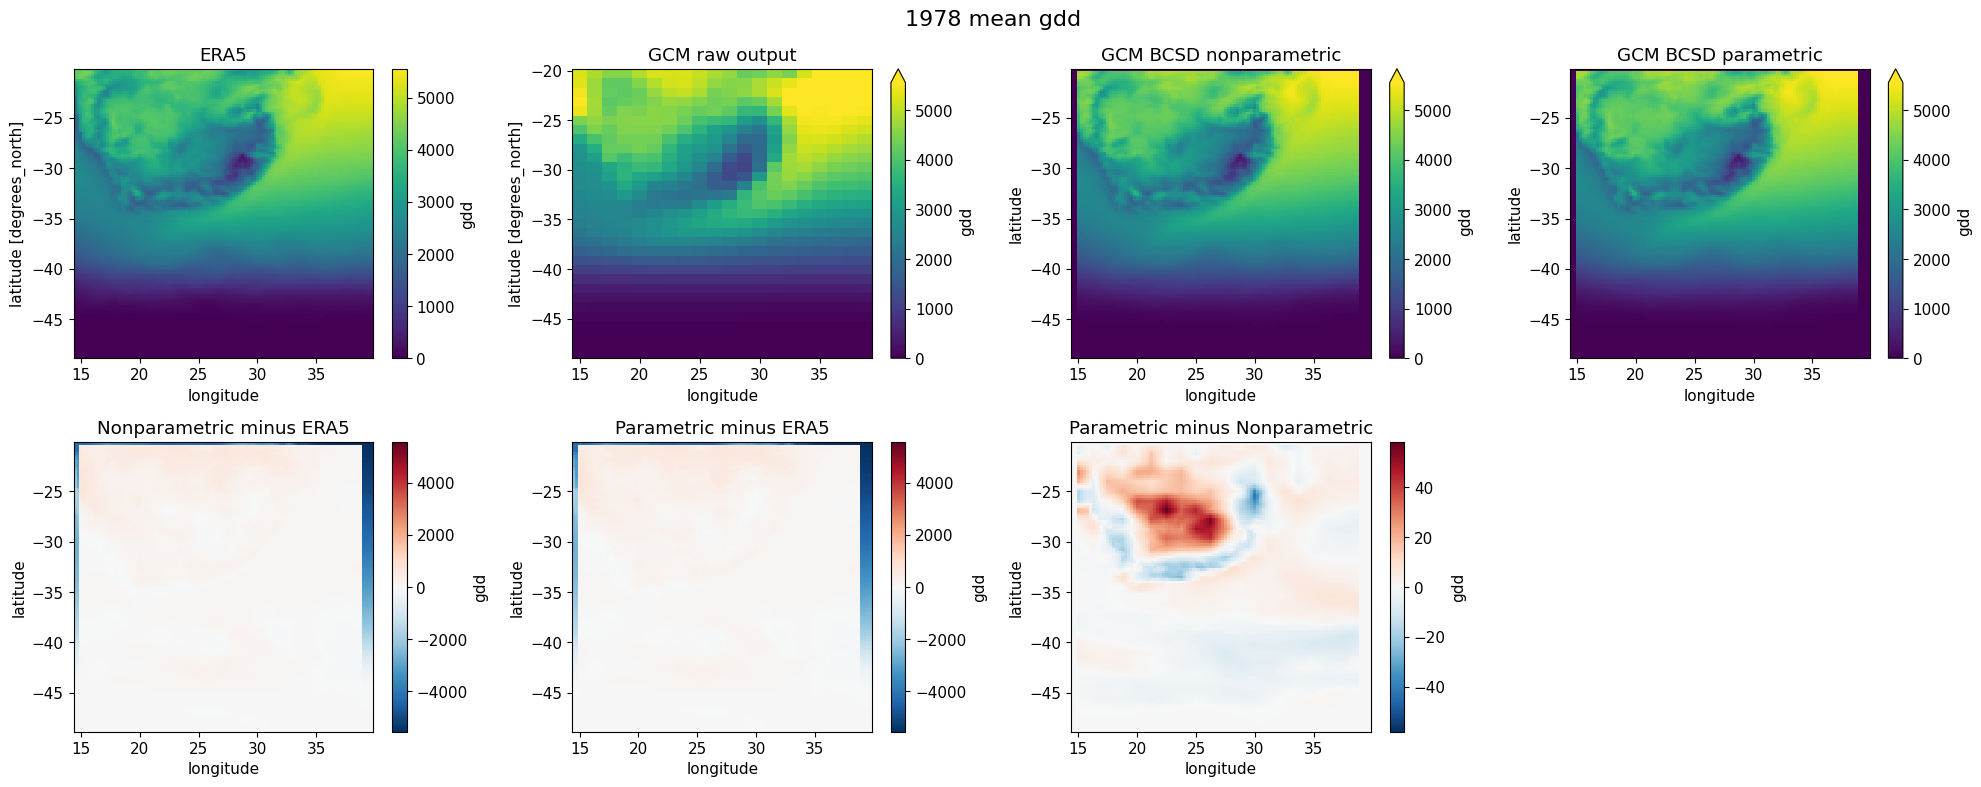

In [64]:
plot_comparisons(era5_gdd_toplot, raw_gdd_toplot, ds1_gdd_toplot, ds2_gdd_toplot)

In [65]:
raw_over30C_toplot, era5_over30C_toplot, ds1_over30C_toplot, ds2_over30C_toplot = (
    calculate_statistic_to_plot(
        raw.isel(time=slice(0, 365)),
        era5.isel(time=slice(0, 365)),
        ds1_tas.isel(time=slice(0, 365)),
        "days_over_30C",
        "tas",
        ds2=ds2_tas.isel(time=slice(0, 365)),
    )
)

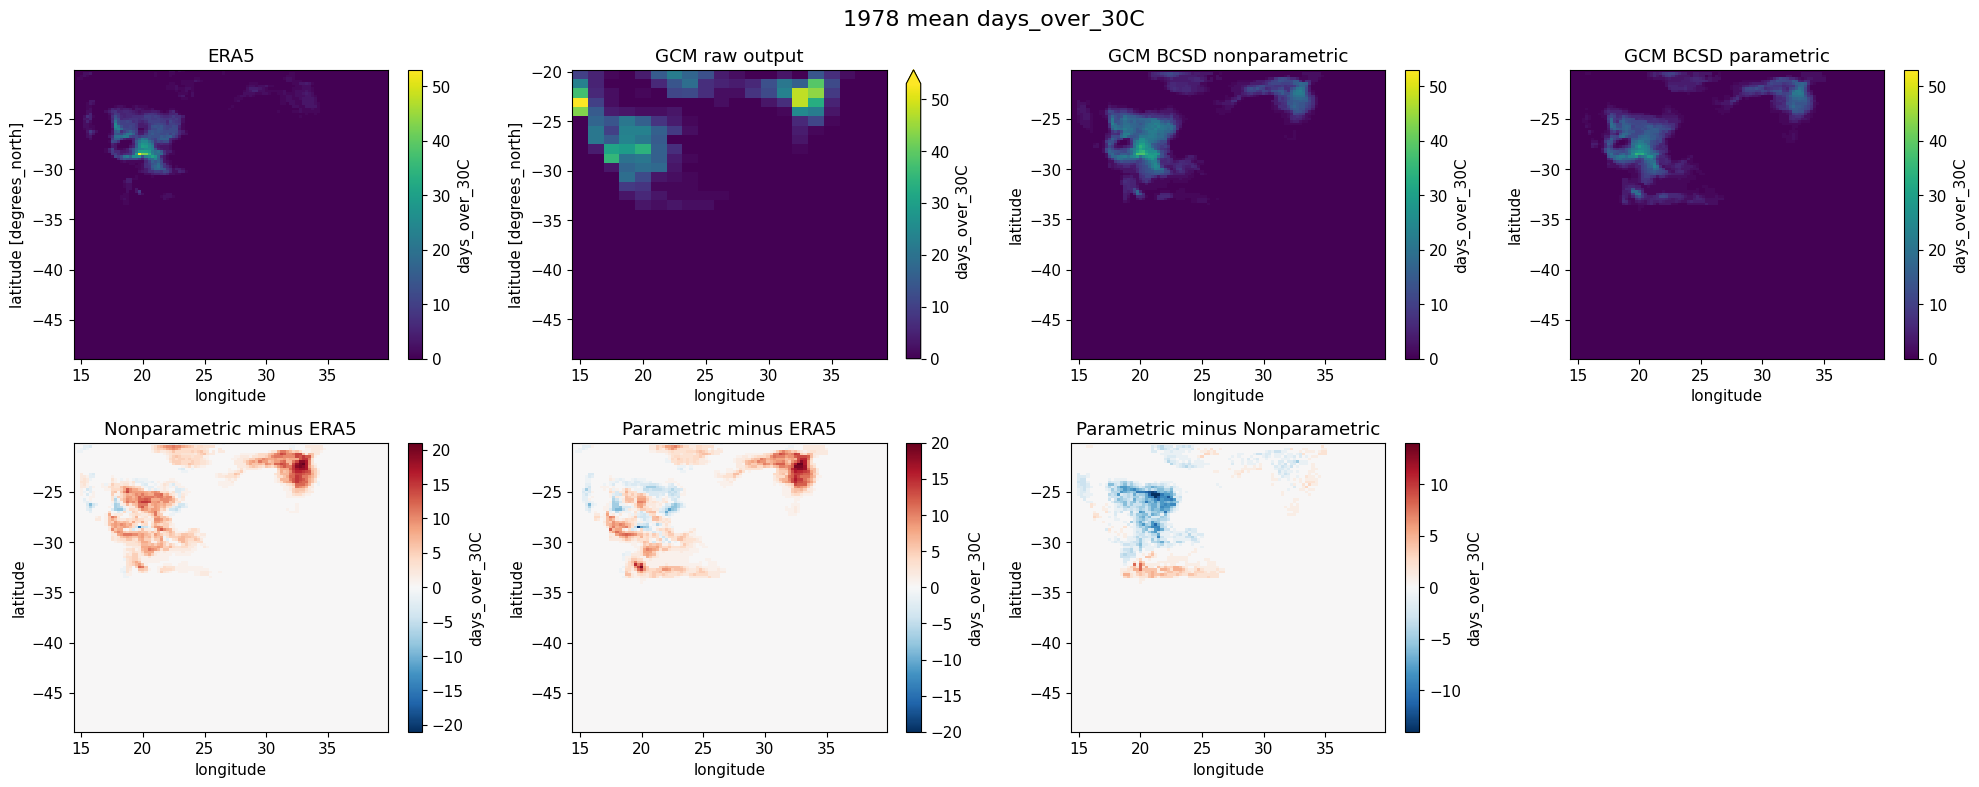

In [66]:
plot_comparisons(era5_over30C_toplot, raw_over30C_toplot, ds1_over30C_toplot, ds2_over30C_toplot)

In [67]:
locations = {
    "Cape Town": (-33.9221, 18.4231),
    # TODO Temi: add in 9 more major cities around the world
    # TODO Temi: add in 10 locations from a variety of climatic zones around the world
}

In [68]:
# temi TODO: write a description here for why we're doing this kind of analysis

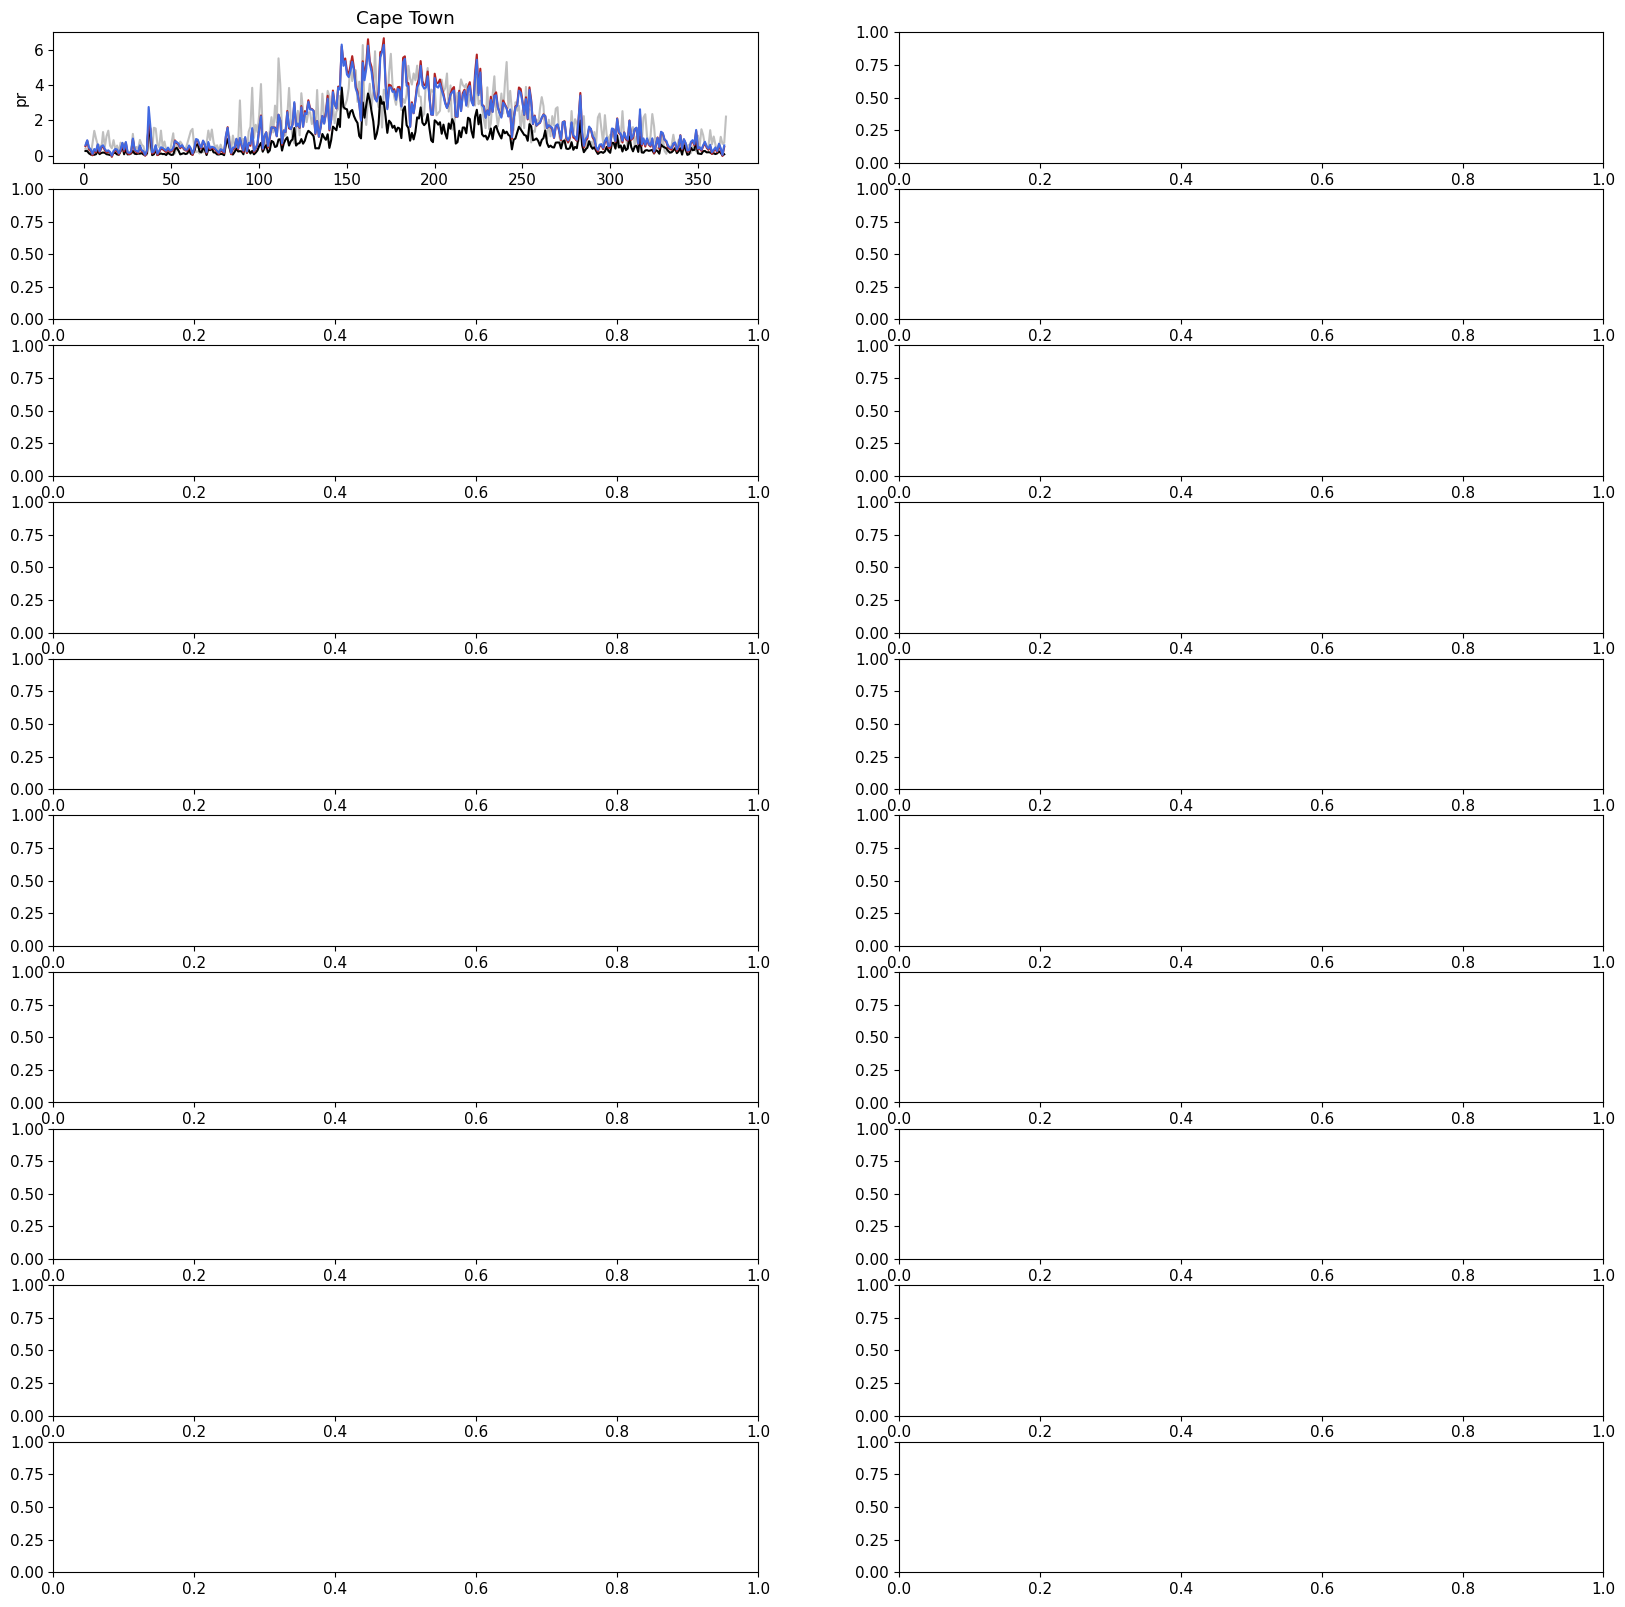

In [69]:
# temi TODO: add three more cells in this notebook, repeating these seasonal cycle plots for tasmax, tasmin, and tas
variable = "pr"
time_slice = slice("1984", "2014")

fig, axarr_shape = plt.subplots(nrows=10, ncols=2, figsize=(20, 20))
axarr = axarr_shape.flatten()
for i, (location, (lat, lon)) in enumerate(locations.items()):
    era5_toplot, raw_toplot, ds1_toplot, ds2_toplot = prep_datasets_for_seasonal_cycle_plotting(
        era5, raw, ds1, time_slice, lat, lon, variable, ds2=ds2
    )

    plot_timeseries(axarr[i], era5_toplot, raw_toplot, ds1_toplot, location, ds2_toplot)
    axarr[i].set_title(location)
    # temi TODO: add a single legend applying to all of the panels of plots, above the figure
    # temi TODO: add a title at the top of this figure (as part of the function) describing the variable and time period
    # temi TODO: fix ylabels to have units

In [70]:
# Make a figure with all of the timeseries for all of the locations for the same time slice
# Repeat for a randomly selected year - for ease of calendar use only choose non-leap year calendars

In [71]:
ds_list = [era5, raw, ds1, ds2]

TypeError: prep_datasets_for_daily_timeseries_plotting() got an unexpected keyword argument 'ds2'

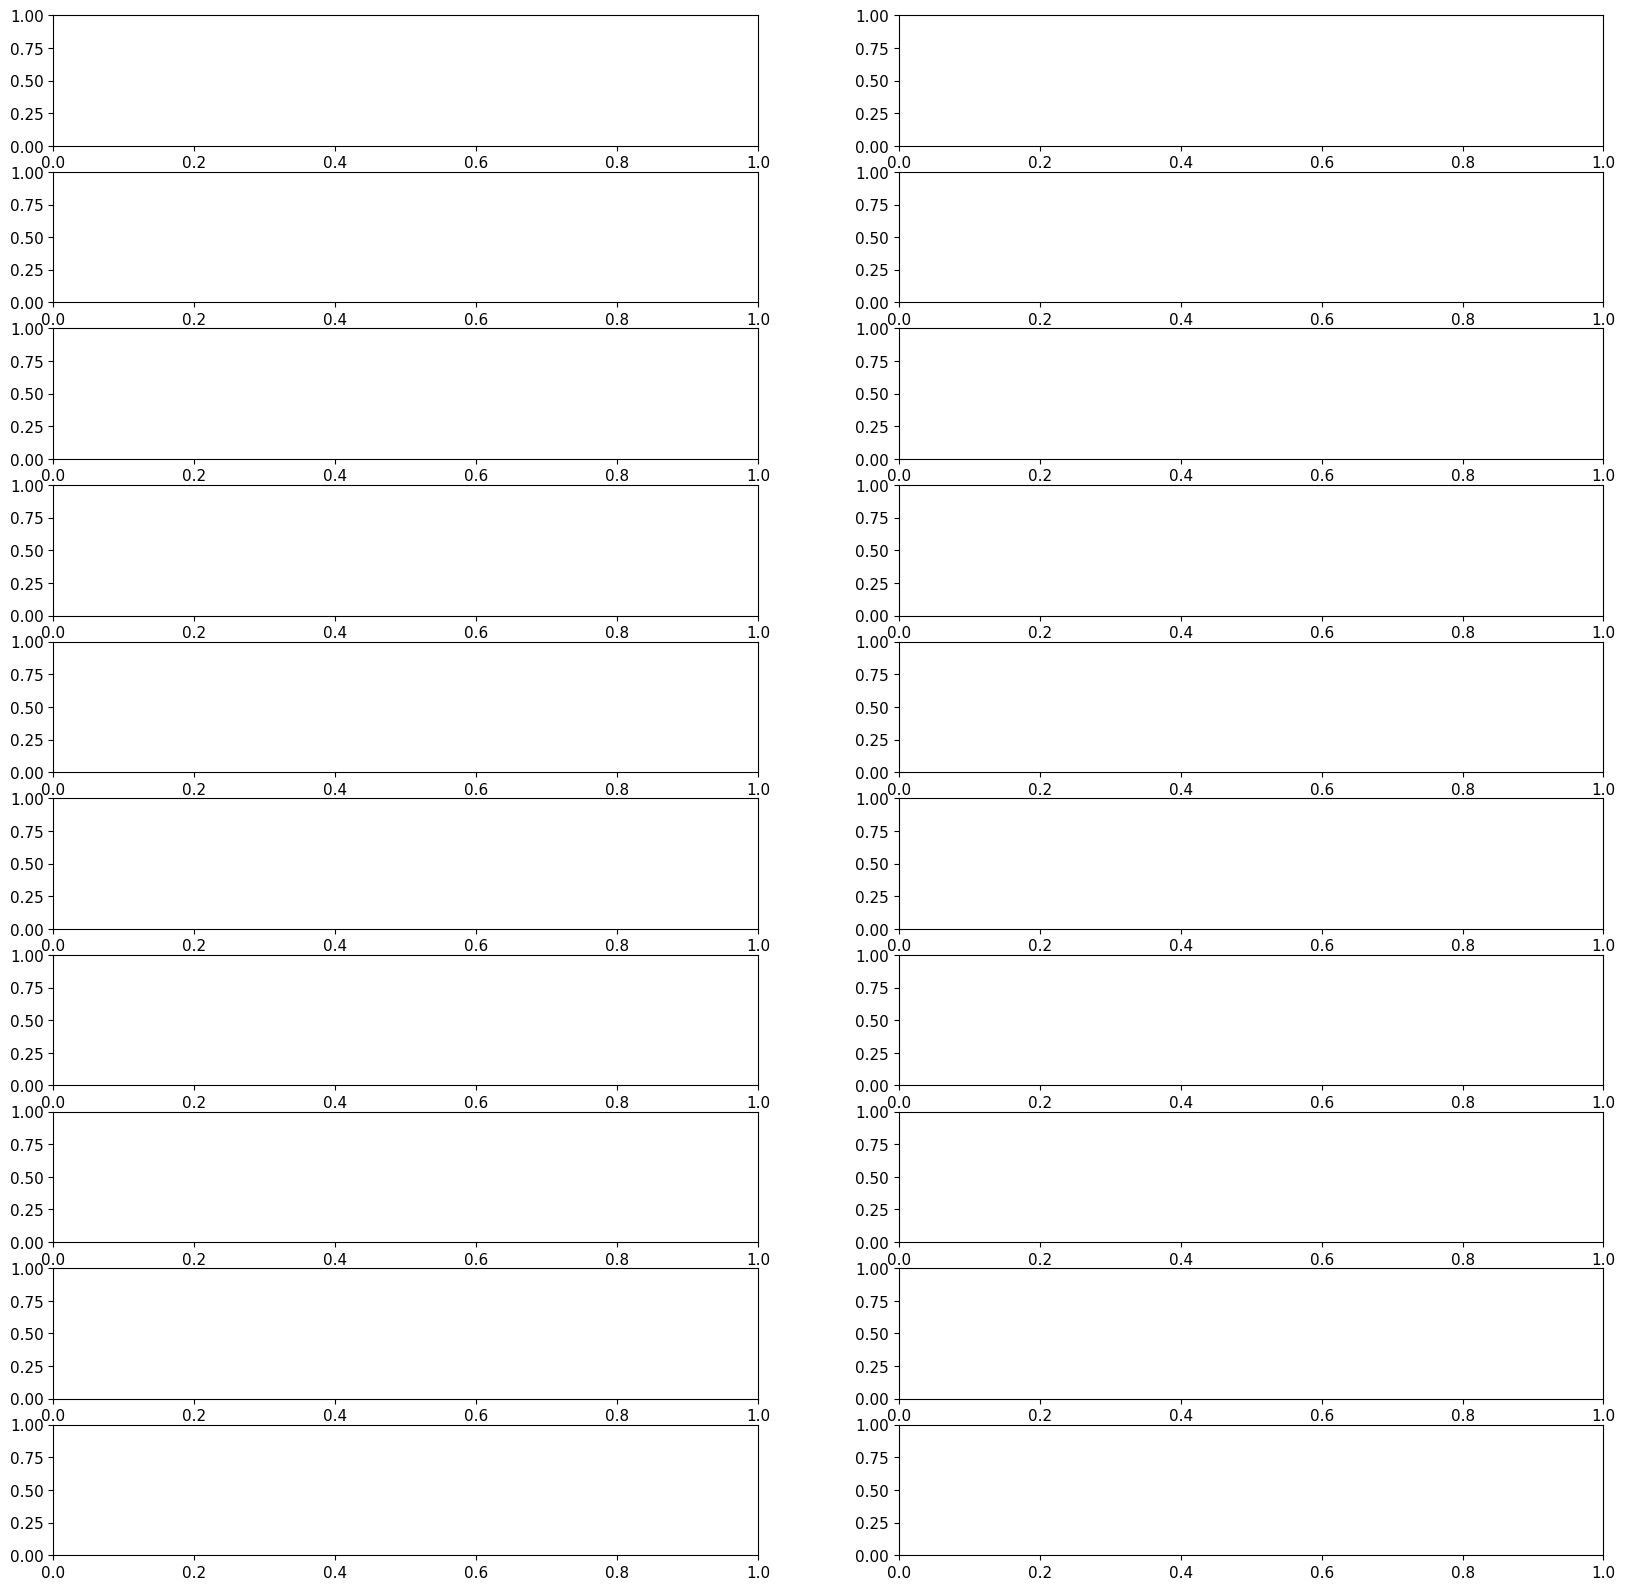

In [72]:
# temi TODO: add three more cells in this notebook, repeating these daily timeseries plots for tasmax, tasmin, and tas
variable = "pr"
time_slice = slice("1989", "1989")

fig, axarr_shape = plt.subplots(nrows=10, ncols=2, figsize=(20, 20))
axarr = axarr_shape.flatten()
# temi TODO: rerun this cell when the locations dict above has 20 locations in it
for i, (location, (lat, lon)) in enumerate(locations.items()):
    era5_toplot, raw_toplot, ds1_toplot, ds2_toplot = prep_datasets_for_daily_timeseries_plotting(
        era5, raw, ds1, time_slice, lat, lon, ds2=ds2
    )
    era5_toplot[variable].plot(ax=axarr[i], color="grey", alpha=0.5)
    raw_toplot[variable].plot(ax=axarr[i], color="k")
    ds1_toplot[variable].plot(ax=axarr[i], color="firebrick")
    ds2_toplot[variable].plot(ax=axarr[i], color="royalblue")
    axarr[i].set_title(location)

    # temi TODO: add a single legend applying to all of the panels of plots, above the figure
    # temi TODO: fix ylabels to have units

In [73]:
era5_toplot = sel_point(era5, lat, lon)[variable]
raw_toplot = sel_point(raw, lat, lon)[variable]
ds1_toplot = sel_point(ds1, lat, lon)[variable]
ds2_toplot = sel_point(ds2, lat, lon)[variable]

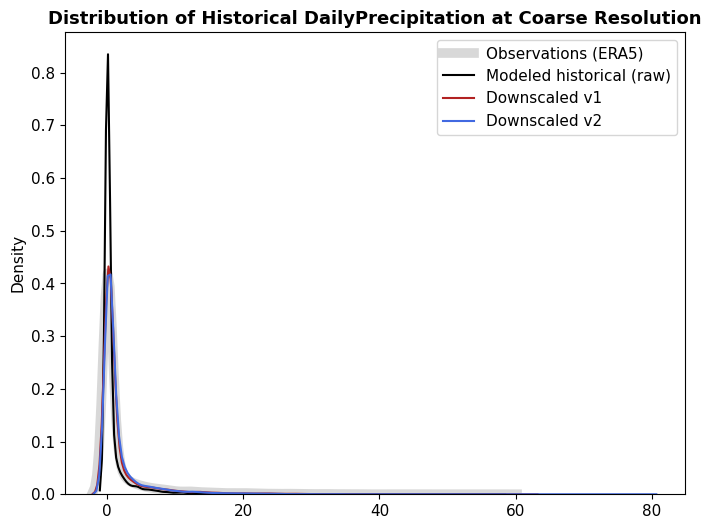

In [74]:
# temi TODO: make a function which create a 20-panel plot like the timeseries above, but each panel is the PDF below.
plot_pdf(
    era5_toplot,
    raw_toplot,
    ds1_toplot,
    "pr",
    ds2=ds2_toplot,
    title="Distribution of Historical DailyPrecipitation at Coarse Resolution",
)

In [75]:
# temi TODO: repeat the PDF figures (and update/extend the `plot_pdf` function as needed) for tasmax, tasmin, tas

A PDF shows how often different rainfall amounts occur, helping to see typical values and variability. A CDF shows the fraction of days with rainfall below a given amount, making it easier to understand how often heavy or extreme rainfall events occur. These plots show that raw GCM output tends to underestimate extreme rainfall events while overestimating the frequency of low rainfall days, a common bias known as the drizzle bias.

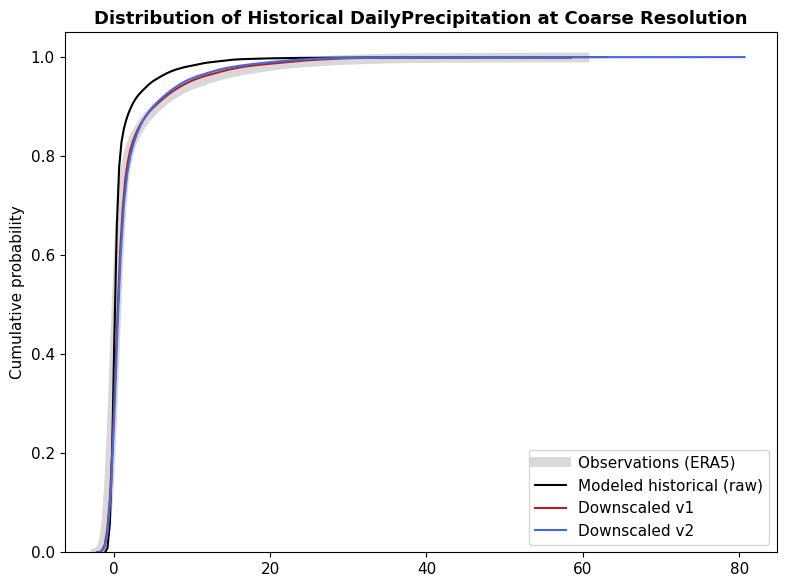

In [78]:
plot_cdf(
    era5_toplot,
    raw_toplot,
    ds1_toplot,
    "pr",
    ds2=ds2_toplot,
    title="Distribution of Historical DailyPrecipitation at Coarse Resolution",
)